In [11]:
%matplotlib inline
import os
import sys
from pathlib import Path
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    from dotenv import load_dotenv
    from sqlalchemy import create_engine
except ImportError as e:
    print(f"Missing dependency: {e}. Install with: pip install pandas seaborn matplotlib sqlalchemy python-dotenv", file=sys.stderr)
    raise SystemExit(1) from e

# Find project root (where .env lives) from notebook dir
_NOTEBOOK_DIR = Path.cwd()
_PROJECT_ROOT = _NOTEBOOK_DIR
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

def _load_env():
    load_dotenv(_PROJECT_ROOT / ".env")

def _db_url():
    host = os.getenv("DB_HOST") or os.getenv("PGHOST", "localhost")
    port = os.getenv("DB_PORT") or os.getenv("PGPORT", "5432")
    user = os.getenv("DB_USER") or os.getenv("PGUSER", "postgres")
    password = os.getenv("DB_PASS") or os.getenv("PGPASSWORD", "")
    dbname = os.getenv("DB_NAME") or os.getenv("PGDATABASE", "baseball")
    pw = quote_plus(password) if password else ""
    return f"postgresql://{user}:{pw}@{host}:{port}/{dbname}"

_load_env()
engine = create_engine(_db_url())


Fetching data...
Plotting Pitch Frequency...
Plotting Hit Frequency...


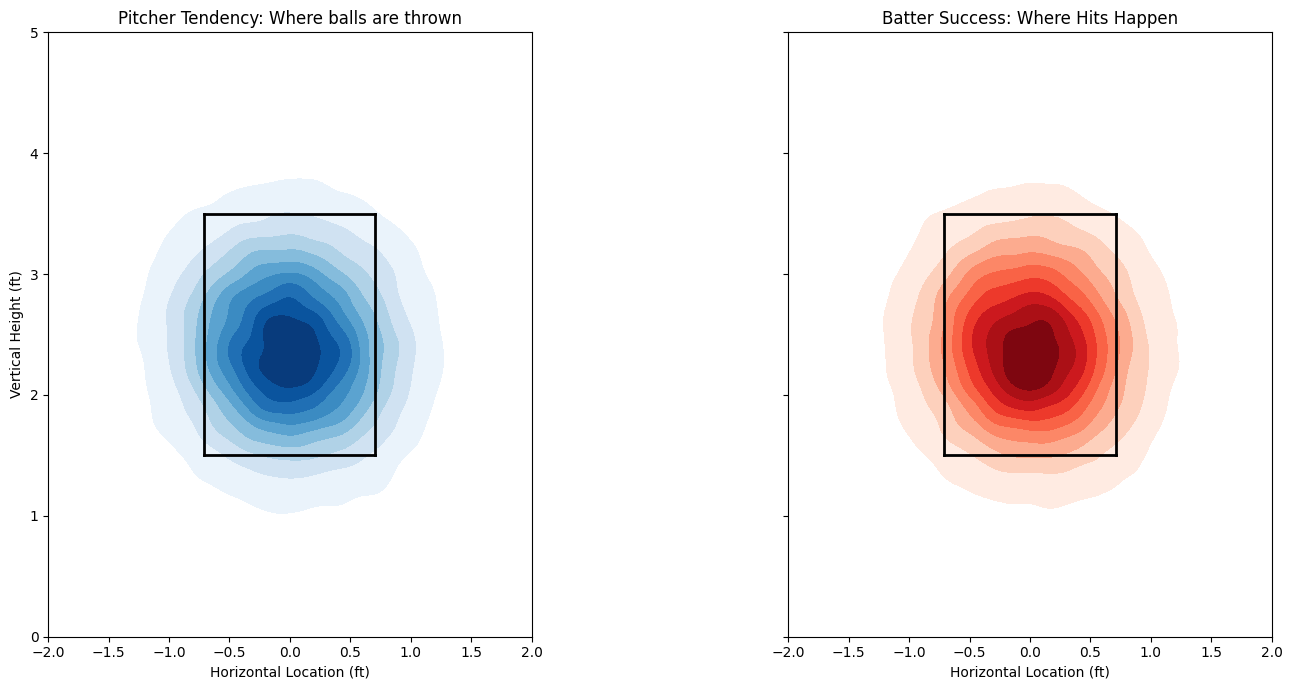

In [ ]:
SAMPLE_SIZE = 50000

df = pd.read_sql("""
    SELECT plate_x, plate_z, events, type
    FROM clean_statcast_with_batter
    WHERE plate_x IS NOT NULL AND plate_z IS NOT NULL AND type = 'X'
""", engine)

if len(df) > SAMPLE_SIZE:
    df_all = df.sample(SAMPLE_SIZE, random_state=42)
else:
    df_all = df

hit_events = ['single', 'double', 'triple', 'home_run']
df_hits = df[df['events'].isin(hit_events)]

def draw_strike_zone(ax):
    ax.plot([-0.708, 0.708], [1.5, 1.5], color="black", lw=2)
    ax.plot([-0.708, 0.708], [3.5, 3.5], color="black", lw=2)
    ax.plot([-0.708, -0.708], [1.5, 3.5], color="black", lw=2)
    ax.plot([0.708, 0.708], [1.5, 3.5], color="black", lw=2)
    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 5)
    ax.set_xlabel("Horizontal Location (ft)")
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.kdeplot(data=df_all, x="plate_x", y="plate_z", fill=True, cmap="Blues", thresh=0.05, ax=axes[0])
draw_strike_zone(axes[0])
axes[0].set_title("Pitcher Tendency: Where balls are thrown")
axes[0].set_ylabel("Vertical Height (ft)")

sns.kdeplot(data=df_hits, x="plate_x", y="plate_z", fill=True, cmap="Reds", thresh=0.05, ax=axes[1])
draw_strike_zone(axes[1])
axes[1].set_title("Batter Success: Where Hits Happen")

plt.tight_layout()
plt.show()

Fetching batted balls with pitch_type...


C:\Users\macia\AppData\Local\Temp\ipykernel_34824\3568144917.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


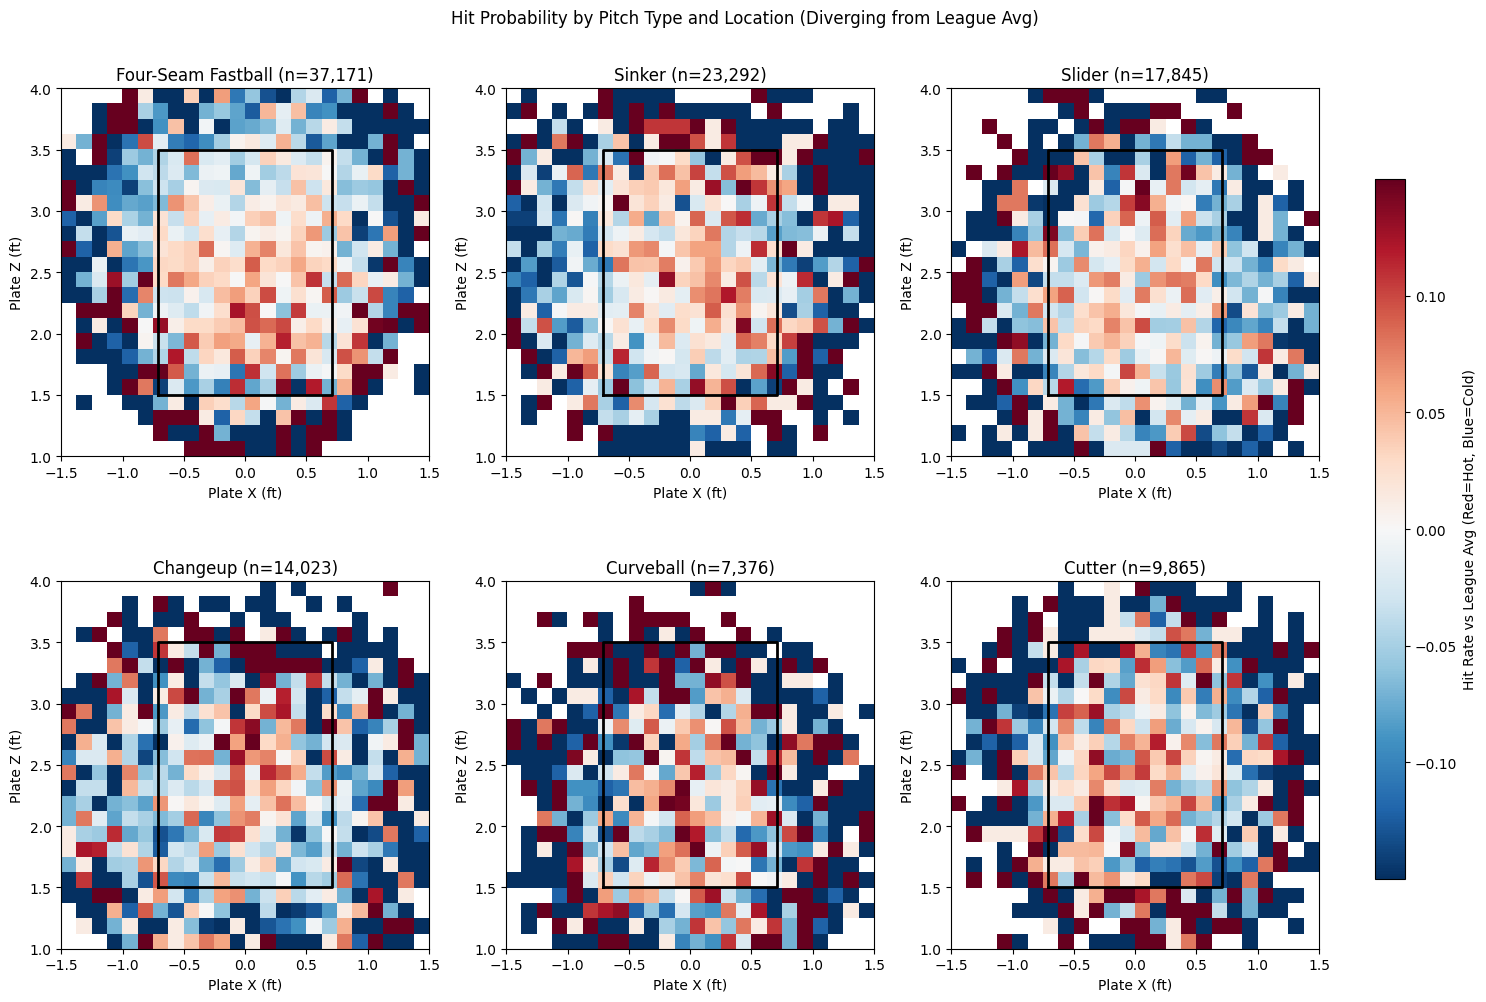

In [ ]:
import numpy as np
from matplotlib.colors import TwoSlopeNorm

PITCH_TYPES = ["FF", "SI", "SL", "CH", "CU", "FC"]
PITCH_LABELS = {
    "FF": "Four-Seam Fastball",
    "SI": "Sinker",
    "SL": "Slider",
    "CH": "Changeup",
    "CU": "Curveball",
    "FC": "Cutter",
}

df_pt = pd.read_sql("""
    SELECT plate_x, plate_z, pitch_type, events
    FROM clean_statcast_with_batter
    WHERE plate_x IS NOT NULL AND plate_z IS NOT NULL
      AND pitch_type IS NOT NULL AND pitch_type != ''
      AND type = 'X'
""", engine)

df_pt["is_hit"] = df_pt["events"].isin(["single", "double", "triple", "home_run"])
league_hit_rate = df_pt["is_hit"].mean()

counts = df_pt.groupby("pitch_type").size()
valid_types = [t for t in PITCH_TYPES if t in counts.index and counts[t] >= 500]
if len(valid_types) < 4:
    valid_types = counts.nlargest(6).index.tolist()

x_edges = np.linspace(-1.5, 1.5, 25)
z_edges = np.linspace(1.0, 4.0, 25)

n_plots = len(valid_types)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
if n_plots == 1:
    axes = np.array([[axes]])
elif axes.ndim == 1:
    axes = axes.reshape(1, -1)

norm = TwoSlopeNorm(vmin=-0.15, vcenter=0, vmax=0.15)

for idx, pt in enumerate(valid_types):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    sub = df_pt[df_pt["pitch_type"] == pt]

    hit_rate_2d, _, _ = np.histogram2d(sub["plate_x"], sub["plate_z"], bins=[x_edges, z_edges], weights=sub["is_hit"].astype(float))
    count_2d, _, _ = np.histogram2d(sub["plate_x"], sub["plate_z"], bins=[x_edges, z_edges])
    with np.errstate(divide="ignore", invalid="ignore"):
        hit_rate_grid = np.where(count_2d > 0, hit_rate_2d / count_2d, np.nan)
    diff = hit_rate_grid - league_hit_rate

    im = ax.imshow(diff.T, origin="lower", extent=[-1.5, 1.5, 1.0, 4.0], aspect="auto", cmap="RdBu_r", norm=norm, interpolation="nearest")
    ax.plot([-0.708, 0.708, 0.708, -0.708, -0.708], [1.5, 1.5, 3.5, 3.5, 1.5], "k-", lw=2)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(1.0, 4.0)
    ax.set_xlabel("Plate X (ft)")
    ax.set_ylabel("Plate Z (ft)")
    ax.set_title(PITCH_LABELS.get(pt, pt) + f" (n={len(sub):,})")
    ax.set_aspect("equal")

for idx in range(len(valid_types), nrows * ncols):
    row, col = idx // ncols, idx % ncols
    axes[row, col].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Hit Rate vs League Avg (Red=Hot, Blue=Cold)")
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.suptitle("Hit Probability by Pitch Type and Location (Diverging from League Avg)", y=1.02, fontsize=12)
plt.show()

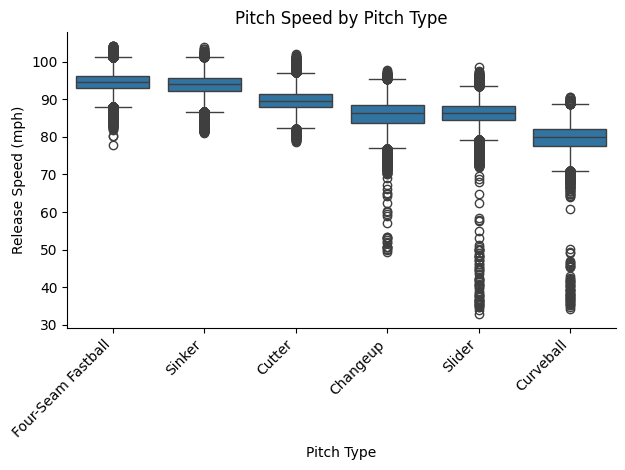

In [22]:
PITCH_TYPES = ["FF", "SI", "SL", "CH", "CU", "FC"]
PITCH_LABELS = {
    "FF": "Four-Seam Fastball",
    "SI": "Sinker",
    "SL": "Slider",
    "CH": "Changeup",
    "CU": "Curveball",
    "FC": "Cutter",
}

df_speed = pd.read_sql("""
    SELECT release_speed, pitch_type
    FROM clean_statcast_with_batter
    WHERE release_speed IS NOT NULL AND pitch_type IN ('FF', 'SI', 'SL', 'CH', 'CU', 'FC')
""", engine)

order = df_speed.groupby("pitch_type")["release_speed"].median().sort_values(ascending=False).index
df_speed["pitch_type_label"] = df_speed["pitch_type"].map(PITCH_LABELS)

sns.boxplot(data=df_speed, x="pitch_type_label", y="release_speed", order=[PITCH_LABELS[pt] for pt in order])
plt.xticks(rotation=45, ha='right')
plt.title("Pitch Speed by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Release Speed (mph)")
sns.despine()
plt.tight_layout()
plt.show()


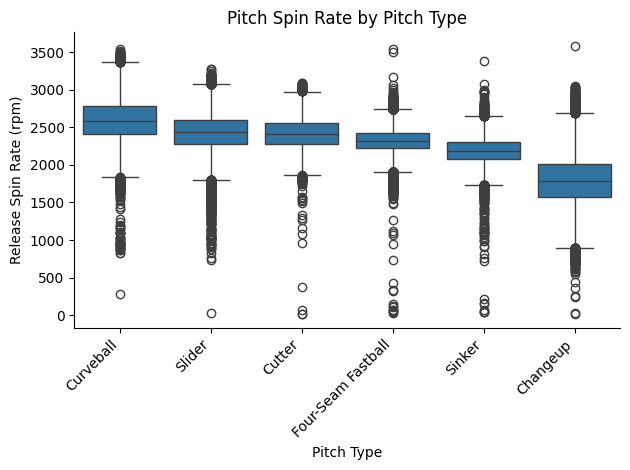

In [21]:
PITCH_TYPES = ["FF", "SI", "SL", "CH", "CU", "FC"]
PITCH_LABELS = {
    "FF": "Four-Seam Fastball",
    "SI": "Sinker",
    "SL": "Slider",
    "CH": "Changeup",
    "CU": "Curveball",
    "FC": "Cutter",
}

try:
    df_spin = pd.read_sql("""
        SELECT release_spin_rate, pitch_type
        FROM clean_statcast_with_batter
        WHERE release_spin_rate IS NOT NULL AND pitch_type IN ('FF', 'SI', 'SL', 'CH', 'CU', 'FC')
    """, engine)
    
    order = df_spin.groupby("pitch_type")["release_spin_rate"].median().sort_values(ascending=False).index
    df_spin["pitch_type_label"] = df_spin["pitch_type"].map(PITCH_LABELS)
    
    sns.boxplot(data=df_spin, x="pitch_type_label", y="release_spin_rate", order=[PITCH_LABELS[pt] for pt in order])
    plt.xticks(rotation=45, ha='right')
    plt.title("Pitch Spin Rate by Pitch Type")
    plt.xlabel("Pitch Type")
    plt.ylabel("Release Spin Rate (rpm)")
    sns.despine()
    plt.tight_layout()
    plt.show()
except Exception:
    pass


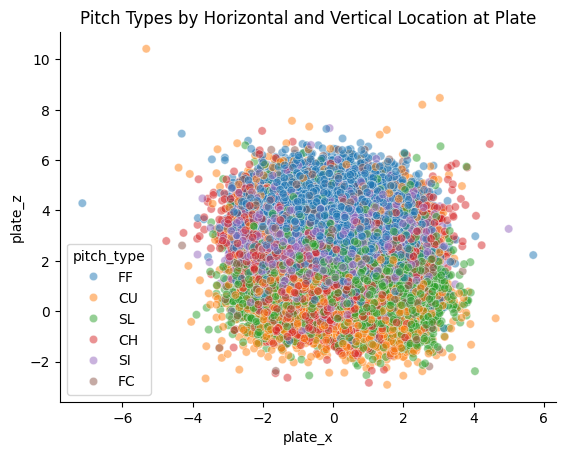

In [20]:
PITCH_TYPES = ["FF", "SI", "SL", "CH", "CU", "FC"]
PITCH_LABELS = {
    "FF": "Four-Seam Fastball",
    "SI": "Sinker",
    "SL": "Slider",
    "CH": "Changeup",
    "CU": "Curveball",
    "FC": "Cutter",
}

df_location = pd.read_sql("""
    SELECT plate_x, plate_z, pitch_type
    FROM clean_statcast_with_batter
    WHERE plate_x IS NOT NULL AND plate_z IS NOT NULL 
      AND pitch_type IN ('FF', 'SI', 'SL', 'CH', 'CU', 'FC')
""", engine)

sns.scatterplot(data=df_location, x="plate_x", y="plate_z", hue="pitch_type", alpha=0.5)
sns.despine()
plt.title("Pitch Types by Horizontal and Vertical Location at Plate")
plt.show()